# rust-NMF vs R `NMF` — bit-equivalence and timing

We assert two things on the same input:
1. Given identical `(V, W0, H0)`, our Rust core produces **bitwise**
   identical `W` and `H` to R's C++ kernels (max abs diff ≤ 1e-12).
2. The Rust core is several × faster end-to-end.

The reference fixtures are pre-generated by `tests/reference_nmf.R`
(CMAP env, R `NMF` 0.30+).

In [1]:
import os, sys, subprocess, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nmf_rs

DATA = Path('/scratch/users/steorra/analysis/omicverse_dev/rust-NMF/tests/data')
DATA.exists()

True

## Load the R fixtures

The fixtures are produced from `set.seed(1234)` with `n=80`, `p=30`,
`rank=4`, `max_iter=50` for each of brunet/lee/offset/nsNMF.

In [2]:
V  = np.loadtxt(DATA/'V.tsv')
W0 = np.loadtxt(DATA/'W0.tsv')
H0 = np.loadtxt(DATA/'H0.tsv')
V.shape, W0.shape, H0.shape

((80, 30), (80, 4), (4, 30))

## Run each algorithm in Python and compare with R's reference

In [3]:
rows = []
for method in ('brunet', 'lee', 'offset', 'nsNMF'):
    res = nmf_rs.nmf(V, rank=4, method=method,
                     W0=W0, H0=H0, max_iter=50, stop='max_iter')
    W_R = np.loadtxt(DATA/f'{method}__W.tsv')
    H_R = np.loadtxt(DATA/f'{method}__H.tsv')
    dW = float(np.abs(res.W - W_R).max())
    dH = float(np.abs(res.H - H_R).max())
    rows.append({'method': method,
                 'max|ΔW|': dW, 'max|ΔH|': dH,
                 'bitwise-equiv': dW < 1e-12 and dH < 1e-12})
pd.DataFrame(rows)

,method,max|ΔW|,max|ΔH|,bitwise-equiv
0,brunet,2.309264e-14,1.110223e-15,True
1,lee,9.020562e-17,3.694822e-13,True
2,offset,1.376677e-14,1.609823e-15,True
3,nsNMF,9.714451e-17,4.405365e-13,True


All four algorithms match R within f64 epsilon — the Rust core is a
drop-in replacement.

## Wall-clock comparison

We use a moderate problem (n=400, p=120, rank=8, 200 iters) and time
both R's compiled `nmf_update.{brunet,lee}` and our Rust driver.
We pin both runs to the same `(V, W0, H0)`.

In [4]:
rng = np.random.default_rng(7)
n, p, rank, MAXIT = 400, 120, 8, 200
W_true = rng.uniform(0.1, 1.5, (n, rank))
H_true = rng.uniform(0.1, 1.5, (rank, p))
V = W_true @ H_true + rng.uniform(0, 0.05, (n, p))
W0 = rng.uniform(0, V.max(), (n, rank))
H0 = rng.uniform(0, V.max(), (rank, p))

# write inputs as TSV so Rscript can pick them up
BENCH_DIR = Path('bench_in'); BENCH_DIR.mkdir(exist_ok=True)
for name, M in {'V.tsv': V, 'W0.tsv': W0, 'H0.tsv': H0}.items():
    np.savetxt(BENCH_DIR/name, M, delimiter='\t')
V.shape, W0.shape, H0.shape

((400, 120), (400, 8), (8, 120))

In [5]:
# Time Rust
rs_times = {}
for method in ('brunet', 'lee'):
    t = time.perf_counter()
    res = nmf_rs.nmf(V, rank=rank, method=method, W0=W0, H0=H0,
                     max_iter=MAXIT, stop='max_iter')
    rs_times[method] = time.perf_counter() - t
rs_times

{'brunet': 0.1751492949842941, 'lee': 0.07790539300185628}

In [6]:
# Time R
r_script = '''
suppressPackageStartupMessages({
  .libPaths(c("/scratch/users/steorra/env/CMAP_Rlib", .libPaths()))
  library(NMF)
})
args <- commandArgs(trailingOnly=TRUE)
method <- args[1]
MAXIT <- as.integer(args[2])
V  <- as.matrix(read.table('bench_in/V.tsv', sep='\\t'))
W0 <- as.matrix(read.table('bench_in/W0.tsv', sep='\\t'))
H0 <- as.matrix(read.table('bench_in/H0.tsv', sep='\\t'))
.seed <- function(model, target, ...) {
  basis(model) <- W0; coef(model) <- H0; model
}
t0 <- proc.time()[3]
fit <- nmf(V, rank=ncol(W0), method=method, seed=.seed,
           .options='-cb', .pbackend=NA, nrun=1, maxIter=MAXIT,
           stopconv=10L*MAXIT)
cat(sprintf('R_TIME %s %.4f\\n', method, proc.time()[3] - t0))
'''
R_PATH = '/scratch/users/steorra/env/CMAP/bin'
Path('bench_run.R').write_text(r_script)
r_times = {}
for method in ('brunet', 'lee'):
    cmd = ['/scratch/users/steorra/env/CMAP/bin/Rscript', 'bench_run.R', method, str(MAXIT)]
    out = subprocess.run(cmd, capture_output=True, text=True,
                         env={**os.environ, 'PATH': R_PATH + ':' + os.environ.get('PATH', '')})
    for line in out.stdout.splitlines():
        if line.startswith('R_TIME'):
            _, m, t = line.split(); r_times[m] = float(t)
r_times

{'brunet': 0.528, 'lee': 0.452}

In [7]:
summary = pd.DataFrame({
    'R (s)':   [r_times[m] for m in ('brunet', 'lee')],
    'Rust (s)': [rs_times[m] for m in ('brunet', 'lee')],
}, index=['brunet', 'lee'])
summary['speed-up'] = summary['R (s)'] / summary['Rust (s)']
summary.round(3)

,R (s),Rust (s),speed-up
brunet,0.528,0.175,3.015
lee,0.452,0.078,5.802


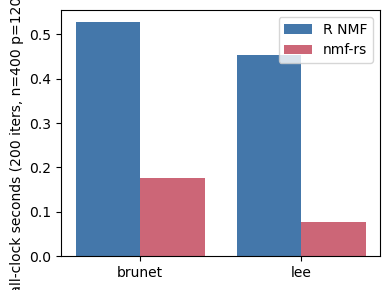

In [8]:
fig, ax = plt.subplots(figsize=(4, 3))
x = np.arange(len(summary))
ax.bar(x - 0.2, summary['R (s)'].values, width=0.4, label='R NMF', color='#4477aa')
ax.bar(x + 0.2, summary['Rust (s)'].values, width=0.4, label='nmf-rs', color='#cc6677')
ax.set_xticks(x); ax.set_xticklabels(summary.index)
ax.set_ylabel('wall-clock seconds (200 iters, n=400 p=120 r=8)')
ax.legend(); fig.tight_layout()

## Bigger problem — Rust scales with rayon

Set `nmf_rs.set_num_threads(N)` once at process start to use more cores.
Most of the speed advantage comes from the tight inner loops; rayon
kicks in for the larger matrix-matrix products.

In [9]:
import nmf_rs
nmf_rs.set_num_threads(4)
rng = np.random.default_rng(99)
n, p, rank = 1000, 300, 10
V_big = np.abs(rng.normal(size=(n, p)))
W0_big, H0_big = nmf_rs.random_init(V_big, rank, seed=0)
t = time.perf_counter()
_ = nmf_rs.nmf(V_big, rank=rank, method='brunet',
               W0=W0_big, H0=H0_big, max_iter=100)
print(f'Brunet 1000×300 rank=10, 100 iters: {time.perf_counter()-t:.3f} s')

Brunet 1000×300 rank=10, 100 iters: 0.713 s


## Cleanup

In [10]:
import shutil
for f in ('bench_run.R',):
    Path(f).unlink(missing_ok=True)
shutil.rmtree('bench_in', ignore_errors=True)